In [ ]:
pip install ucimlrepo

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
%matplotlib inline

In [ ]:
df=pd.read_csv("/content/sample_data/Online Retail.csv")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,01-12-2010 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
37000,539453,84659A,WHITE TRAVEL ALARM CLOCK,3.0,17-12-2010 17:08,2.51,NaN,United Kingdom
37001,539453,84685,BEACH HUT KEY CABINET,1.0,17-12-2010 17:08,7.62,NaN,United Kingdom
37002,539453,84688,BEACH HUT DESIGN BLACKBOARD,1.0,17-12-2010 17:08,8.47,NaN,United Kingdom
37003,539453,84754,S/15 SILVER GLASS BAUBLES IN BAG,1.0,17-12-2010 17:08,2.51,NaN,United Kingdom


In [ ]:
df.groupby(['Quantity']).count()

,InvoiceNo,StockCode,Description,InvoiceDate,UnitPrice,CustomerID,Country
Quantity,,,,,,,
-9360.0,1,1,1,1,1,1,1
-723.0,1,1,1,1,1,0,1
-500.0,1,1,1,1,1,1,1
-320.0,1,1,0,1,1,0,1
-300.0,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...
1488.0,1,1,1,1,1,1,1
1728.0,1,1,1,1,1,1,1
1824.0,1,1,1,1,1,1,1


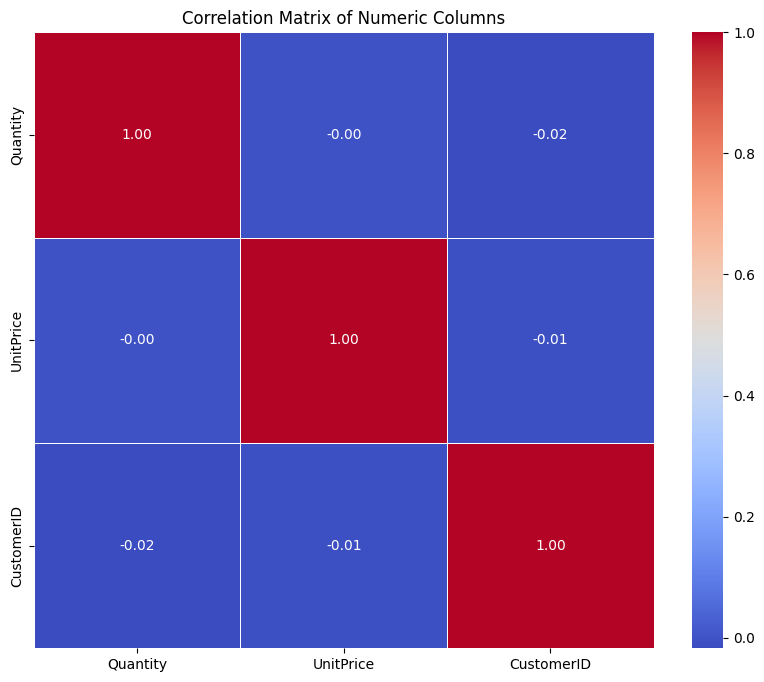

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Columns')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37005 entries, 0 to 37004
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    37005 non-null  object 
 1   StockCode    37004 non-null  object 
 2   Description  36887 non-null  object 
 3   Quantity     37004 non-null  float64
 4   InvoiceDate  37004 non-null  object 
 5   UnitPrice    37004 non-null  float64
 6   CustomerID   24364 non-null  float64
 7   Country      37004 non-null  object 
dtypes: float64(3), object(5)
memory usage: 2.3+ MB


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,37004.000000,37004.000000,24364.000000
mean,8.059156,6.228784,15541.009769
std,61.664063,149.270176,1730.504495
min,-9360.000000,0.000000,12347.000000
25%,1.000000,1.280000,14210.000000
50%,2.000000,2.510000,15570.000000
75%,7.250000,4.250000,17158.000000
max,2880.000000,13541.330000,18269.000000


In [ ]:
X=df.drop(['Quantity'],axis=1)
y=df['Quantity']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

In [ ]:
k = 3
X_train_numeric = X_train.select_dtypes(include=np.number)
X_test_numeric = X_test.select_dtypes(include=np.number)

# Drop rows with missing values in X_train_numeric and y_train
X_train_numeric = X_train_numeric.dropna()
y_train_cleaned = y_train[X_train_numeric.index]

# Train Model and Predict
knn_classifier = KNeighborsClassifier(n_neighbors=k)
knn_model = knn_classifier.fit(X_train_numeric, y_train_cleaned)

In [ ]:
# Drop rows with missing values in X_test_numeric
X_test_cleaned = X_test_numeric.dropna()

# Get the corresponding y_test values for the cleaned X_test_numeric
y_test_cleaned = y_test[X_test_cleaned.index]

yhat = knn_model.predict(X_test_cleaned)

In [ ]:
print("Test set Accuracy: ", accuracy_score(y_test_cleaned, yhat))

Test set Accuracy:  0.4284236657012826


In [ ]:
Ks = 30
acc = np.zeros((Ks))
std_acc = np.zeros((Ks))
for n in range(1,Ks+1):
    #Train Model and Predict
    knn_model_n = KNeighborsClassifier(n_neighbors = n).fit(X_train_numeric, y_train_cleaned)
    yhat = knn_model_n.predict(X_test_cleaned)
    acc[n-1] = accuracy_score(y_test_cleaned, yhat)
    std_acc[n-1] = np.std(yhat==y_test_cleaned)/np.sqrt(yhat.shape[0])

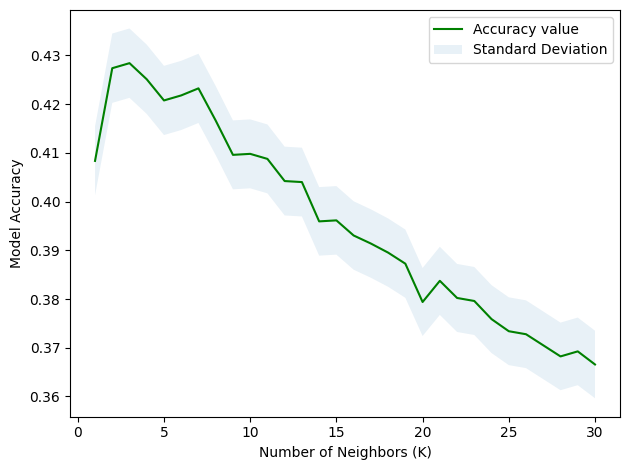

In [ ]:
plt.plot(range(1,Ks+1),acc,'g')
plt.fill_between(range(1,Ks+1),acc - 1 * std_acc,acc + 1 * std_acc, alpha=0.10)
plt.legend(('Accuracy value', 'Standard Deviation'))
plt.ylabel('Model Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.tight_layout()
plt.show()

In [ ]:
print( "The best accuracy was with", acc.max(), "with k =", acc.argmax()+1)

The best accuracy was with 0.4284236657012826 with k = 3


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
print("\nKNN Testing Data Classification Report:")
print(classification_report(y_test_cleaned, yhat))


KNN Testing Data Classification Report:
              precision    recall  f1-score   support

      -240.0       0.00      0.00      0.00         1
      -144.0       0.00      0.00      0.00         1
       -50.0       0.00      0.00      0.00         2
       -48.0       0.00      0.00      0.00         2
       -47.0       0.00      0.00      0.00         1
       -36.0       0.00      0.00      0.00         2
       -24.0       0.00      0.00      0.00         3
       -20.0       0.00      0.00      0.00         1
       -16.0       0.00      0.00      0.00         1
       -12.0       0.00      0.00      0.00         6
       -11.0       0.00      0.00      0.00         1
       -10.0       0.00      0.00      0.00         1
        -8.0       0.11      0.50      0.18         2
        -7.0       0.00      0.00      0.00         1
        -6.0       0.00      0.00      0.00         6
        -4.0       0.00      0.00      0.00        11
        -3.0       0.00      0.00      0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import log_loss, mean_absolute_error,mean_squared_error, r2_score
print("MAE:", mean_absolute_error(y_test_cleaned, yhat))
rmse = np.sqrt(mean_squared_error(y_test_cleaned, yhat))
print("RMSE:", rmse)

# R² Score Example
print("R² Score:", r2_score(y_test_cleaned, yhat))


MAE: 7.898014067025238
RMSE: 39.96864461989354
R² Score: 0.02228067856851368


In [ ]:
# Reiterate findings based on previous analysis

# Best K value and accuracy
best_k = acc.argmax() + 1
best_accuracy = acc.max()
print(f"The best accuracy achieved with KNN was {best_accuracy:.4f} at K = {best_k}")

# Influence of K on accuracy and variance (referencing the plot)
print("\nInfluence of K on Model Accuracy and Variance (referencing the plot):")
print("- As K increases from 1, accuracy generally increases up to K=3, then decreases.")
print("- The standard deviation (variance) generally decreases as K increases.")

# Misclassified categories and potential class overlap (referencing the confusion matrix)
print("\nInsights from Misclassified Categories (referencing the confusion matrix):")
print("- Misclassifications (non-zero off-diagonal values in the confusion matrix) indicate that the model is confusing certain quantity values.")
print("- This suggests potential overlap in the feature space between items with different actual quantities.")

# Feature Normalization
print("\nFeature Normalization:")
print("- We used StandardScaler to normalize the 'Quantity' and 'UnitPrice' features.")
print("- Normalization is important for distance-based algorithms like KNN to ensure features with larger scales don't dominate distance calculations.")

# Scalability Limitations
print("\nScalability Limitations:")
print("- KNN stores the entire training dataset, which can be memory-intensive for large datasets.")
print("- Prediction involves calculating distances to all training instances, which can be computationally expensive for large datasets.")

# Note on Regression Model Performance
print("\nNote on Regression Model Performance:")
print("""MAE: 7.898014067025238
RMSE: 39.96864461989354
R² Score: 0.02228067856851368""")

The best accuracy achieved with KNN was 0.4284 at K = 3

Influence of K on Model Accuracy and Variance (referencing the plot):
- As K increases from 1, accuracy generally increases up to K=3, then decreases.
- The standard deviation (variance) generally decreases as K increases.

Insights from Misclassified Categories (referencing the confusion matrix):
- Misclassifications (non-zero off-diagonal values in the confusion matrix) indicate that the model is confusing certain quantity values.
- This suggests potential overlap in the feature space between items with different actual quantities.

Feature Normalization:
- We used StandardScaler to normalize the 'Quantity' and 'UnitPrice' features.
- Normalization is important for distance-based algorithms like KNN to ensure features with larger scales don't dominate distance calculations.

Scalability Limitations:
- KNN stores the entire training dataset, which can be memory-intensive for large datasets.
- Prediction involves calculating dist

In [ ]:
print("Scalability Limitations of KNN for Large Datasets:")
print("\nMemory Limitations:")
print("One significant limitation of KNN is its memory requirement. During the training phase, KNN does not learn a model with fixed parameters; instead, it essentially 'remembers' the entire training dataset. This means that as the size of the training data increases, the memory needed to store this data also increases proportionally. For large datasets with millions of data points, storing the entire dataset in memory can quickly become infeasible, exceeding available RAM and leading to performance issues or crashes.")

print("\nComputational Cost of Prediction:")
print("The computational cost of making predictions with KNN is another major drawback, especially for large datasets. To predict the class or value of a new data point, KNN calculates the distance between this new point and *every single* data point in the training set. It then identifies the K nearest neighbors and uses their information for prediction. This process of calculating distances to all training instances becomes computationally expensive and slow as the number of training data points grows. In a real-time recommendation system where quick predictions are crucial, this can lead to unacceptable latency.")

print("\nImpact on a Real-World Recommendation System:")
print("In a real-world recommendation system with a massive number of users and items, these scalability limitations would severely impact the feasibility of using a pure KNN approach. The dataset would be enormous, requiring prohibitive amounts of memory to store. Furthermore, generating recommendations for a user would involve calculating distances to potentially all past user-item interactions, leading to extremely slow response times. This would make the system impractical for providing timely and personalized recommendations to a large user base.")

print("\nAlternative Scalable Approaches:")
print("Given the scalability limitations of KNN for large-scale recommendation systems, more scalable alternative approaches are typically employed. These include:")
print("- **Matrix Factorization Methods:** Techniques like Singular Value Decomposition (SVD) or Alternating Least Squares (ALS) decompose the user-item interaction matrix into lower-dimensional latent factor matrices, significantly reducing storage requirements and prediction time.")
print("- **Deep Learning Models:** Architectures such as Neural Collaborative Filtering (NCF), Convolutional Neural Networks (CNNs), or Recurrent Neural Networks (RNNs) can learn complex user and item representations and interaction patterns. These models can be trained on large datasets and offer more efficient prediction compared to pure KNN.")
print("- **Approaches using approximate nearest neighbors:** For very high dimensional data, methods like locality-sensitive hashing (LSH) or tree-based methods can be used to find approximate nearest neighbors more efficiently than a brute-force search.")

Scalability Limitations of KNN for Large Datasets:

Memory Limitations:
One significant limitation of KNN is its memory requirement. During the training phase, KNN does not learn a model with fixed parameters; instead, it essentially 'remembers' the entire training dataset. This means that as the size of the training data increases, the memory needed to store this data also increases proportionally. For large datasets with millions of data points, storing the entire dataset in memory can quickly become infeasible, exceeding available RAM and leading to performance issues or crashes.

Computational Cost of Prediction:
The computational cost of making predictions with KNN is another major drawback, especially for large datasets. To predict the class or value of a new data point, KNN calculates the distance between this new point and *every single* data point in the training set. It then identifies the K nearest neighbors and uses their information for prediction. This process of calculat